# Hypotesetest for parede Temperaturdata

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special

Jeg vil gi et eksempel på en hypotesetest som tar utgangspunkt i
temperaturene i Bergen vi studerte i første uken av dette kurset.

Temperaturene ser ut til å ha økt i perioden vi har
målinger for.

La oss gjette på at temperaturen har økt med mere enn en grad i
gjennomsnitt.

Mere presist vil jeg gjøre utsagnet at på en tilfeldig kalenderdag
er temperaturen mere enn en grad høyere
enn den var på den samme kalenderdagen i året 40 år tidligere.

Jeg vil bruke de daglige temperaturmålingene i de siste 3652
dagene (de siste ti årene) og de 3652 dagene som var 40 år tidligere
for å teste denne hypotesen.

For $i = 1, \dots, 3652$ la $y_i$ være differansen mellom temperaturen for $i$ dager og $10$ år siden
og temperaturen for $i$ dager og $40$ år siden.

Mitt gjett er at
tallene $y_i$ er trukket fra en sannsynlighetsfordeling med gjennomsnitt $\mu$ og at
$\mu > \mu_0$ for $\mu_0 = 1 \ C^{\circ}$.

Jeg forventer at gjennomsnittet $E(y)$ av tallene $y_i$ er nær $\mu$, men jeg vil gjerne vite hvor stort det skal være for at jeg kan være rimelig sikker på at $\mu > \mu_0 = 1 \ C^{\circ}$.

## Vil teste:

**Antatt gjennomsnittsverdi** $\mu_0 = 1 \ C^{\circ}$

**Nullhypotese ($H_0)$:** $\mu = \mu_0$.

**Alternativ hypotese ($H_a$):** $\mu > \mu_0$.

Vi laster inn temperaturdata og beregner forskjellen mellem temperatur på hver kalenderdag og kalenderdagen 40 år tidliger for alle dager 10 år tilbake i tid

In [2]:
# Her importeres Point og Daily funksjonalitetene fra meteostat modulen.
# Hvis meteostat ikke allerede er installert blir den installert.
try:
  import meteostat
except:
  !pip install meteostat
  import meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 18.9 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requi

In [3]:
# Her importeres modulen pandas som pd sammen med numpy og matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t



In [4]:
# Her importeres funksjonaliteten datetime fra modulen datetime.
# Datetime gir oss en bekvem måte å jobbe med tidsdate på.

from datetime import datetime, timedelta

In [5]:
# Sett tidsperioden vi vil hente data fra
# Data for fremtiden kan ikke lastes inn, så når vi ber om å laste inn data får vi data helt opp til i dag.

start = datetime(1973, 1, 1)
end = datetime.today()

In [9]:
from meteostat import config
config.block_large_requests = False

In [10]:
# Målestasjon Florida Bergen
data = meteostat.daily('01317', start, end)
data = data.fetch()

In [11]:
# setter endedato til å være siste dag vi har data for
end = min(data.index[-1], end)

In [12]:
# Insisterer på å ha en rad for hver dag. Uten hull!
data = data.resample('D').mean()

In [13]:
# Setter manglende observasjoner lik morgendagens observasjon
data = data.ffill(axis='index')

In [17]:
data

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
1973-01-01,7.0,5.9,7.7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1973-01-02,7.6,6.4,8.6,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1973-01-03,5.2,3.7,7.7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1973-01-04,6.3,4.8,8.6,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1973-01-05,7.8,5.0,8.5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-03,4.1,2.4,6.8,68.0,7.3,0.0,18.7,7.9,1003.1,<NA>,5.0
2026-04-04,5.3,1.9,8.4,80.0,1.1,0.0,12.8,7.9,1001.3,<NA>,7.0
2026-04-05,5.6,4.2,6.9,81.0,15.9,0.0,22.9,7.9,988.0,<NA>,8.0


In [14]:
# Beregner forskjellen y mellem temperatur på hver kalenderdag og kalenderdagen 40 år tidliger for alle dager 10 år tilbake i tid

antall_år_sammenligne = 10
y1 = data.loc[end - timedelta(days=int(365.2425 * antall_år_sammenligne)): end]['temp'].values
y2 = data.loc[end - timedelta(days=int(365.2425 * antall_år_sammenligne)) - timedelta(days=int(365.2425 * 40)): end - timedelta(days=int(365.2425 * 40))]['temp'].values
y = np.array(y1 - y2)

In [15]:
# Lager pandas dataframe med temperaturdifferanser.
# Dette for å ha funksjonaliteten til pandas tilgjengelig.

data2 = pd.DataFrame(y, columns=['temperaturdifferanse'], index=data.loc[end - timedelta(days=int(365.24 * antall_år_sammenligne)): end].index)

<Axes: xlabel='time'>

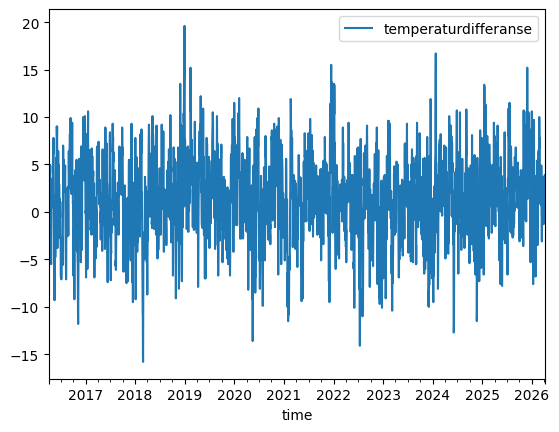

In [16]:
data2.plot(y=['temperaturdifferanse'])

In [18]:
y

array([ 2.8,  0. , -1.4, ...,  1.4,  3.9,  2.2])

## Normalfordeling

I mange situasjoner observerer vi noe som varierer av en sammensatt grunn.

En typisk egenskap ved observasjoner som varierer av samensatte årsaker er at de ofte får en **normalfordeling**.

Med mindre vi har spesiell grunn til å tro noe annet, så regner vi med at
observasjonene våre varier med en tilnærmet normalfordeling.

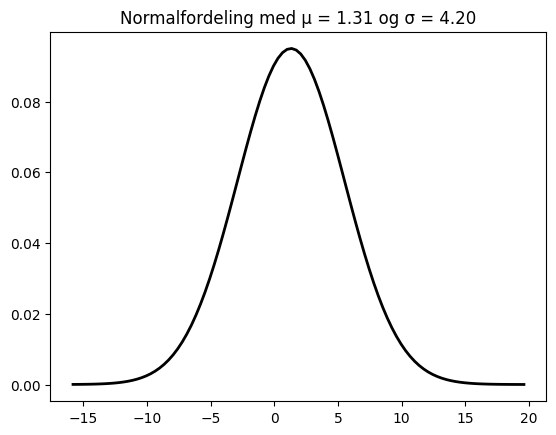

In [19]:
# Plotter normalfordeling med samme gjennomsnitt of standardavvik som observasjonene våre

xmin = np.min(y)
xmax = np.max(y)
mu, std = scipy.stats.norm.fit(data2['temperaturdifferanse'])
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Normalfordeling med μ = {:.2f} og σ = {:.2f}".format(mu, std)
plt.title(title);

## Kriterier for hypotesetest

For å teste hypotesen om temperaturforskjeller vil jeg bruke en $t$-test.

Jeg har ett
utvalg av temperaturforskjeller $y_1, \dots, y_{3653}$.

Nullhypotesen
er at disse tallene er trukket fra en normalfordeling med gjennomsnitt $1 \ C^{\circ}$.

Den alternative hypotesen er at tallene er trukket fra en normalfordeling med et gjennomsnitt som er
høyere enn $1 \ C^{\circ}$.

En forutsetning for å kunne bruke en $t$-test er at observasjonene er
uavhengige og normalfordelte.

Jeg vet ikke på forhånd om temperaturforskjellene er normalfordelte,
men jeg kan danne meg en formening om dette ved å se på et histogram.

Jeg kan finne normalfordelingskurven som passer best til
mitt data og sammenligne den med data.

Hvis det ser bra ut kan jeg fortsette. Ellers må jeg finne en annen
metode eller en annen hypotese.

Uavhengighet betyr at verdien på ett av tallene ikke påvirker verdien på de andre tallene.

**Denne forutsetningen er tvilsom for temperaturdata.** Temperaturen i går og i dag er ikke uavhengige. At jeg ser på temperaturforskjeller gør at tallene kanskje er litt mere uavhengige, men ikke helt!

**Sjekker normalfordeling på data:**

Plotter først et histogram av data.

(Teller datapunkter i hvert delintervall i en oppdeling av intervallet av observerte verdier.)

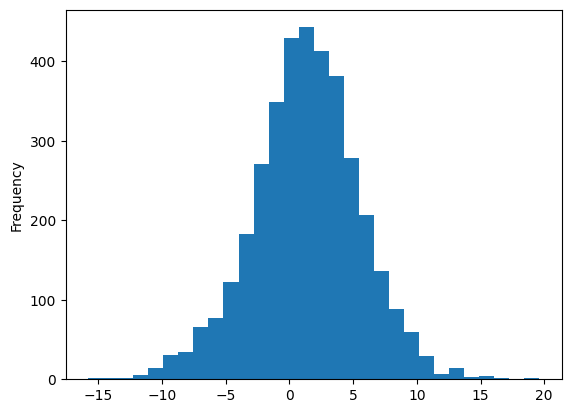

In [20]:
# Plotter histogram av temperaturdifferanser.
data2['temperaturdifferanse'].plot.hist(bins=30)
xmin, xmax = plt.xlim()

Plotter deretter normalfordelingen med samme gjennomsnitt $E(y)$ og standardavvik $\sigma(y)$ som data opp på histogrammet for data.

Formlene for $E(y)$ og $\sigma(y)$ er

$$E(y) = \frac{y_1 + \dots + y_{3653}}{3653}$$

$$\sigma(y) = \sqrt{E(y^2) - E(y)^2}$$

der

$$E(y^2) = \frac{y_1^2 + \dots + y^2_{3653}}{3653}$$

Jeg kan visuellt vurdere om det ut som om at data er normalfordelt.

Her under ser data ganske normalfordelt ut.

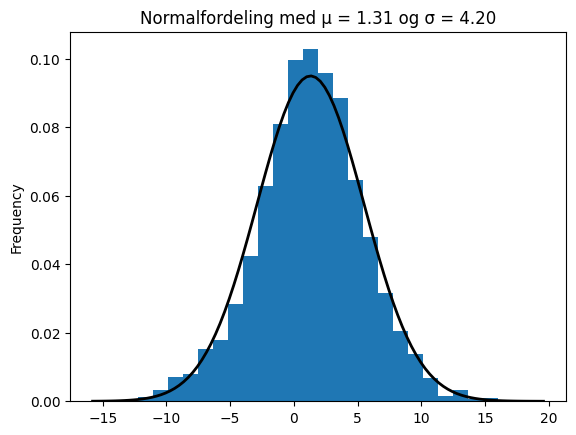

In [21]:
mu, std = scipy.stats.norm.fit(data2['temperaturdifferanse'])
data2['temperaturdifferanse'].plot(kind='hist', bins=30, density=True)
range = np.arange(-10, 10, 0.01)
# plt.plot(range, norm.pdf(range,0,4))
xmin = np.min(y)
xmax = np.max(y)
#xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Normalfordeling med μ = {:.2f} og σ = {:.2f}".format(mu, std)
plt.title(title);
plt.savefig('normal_sjekk.png')

Siden data ser normalfordelt ut antar jeg at gjennomsnittet $E(y)$ er trukket fra en $t$-fordeling med $n - 1 = 3052$ frihetsgrader.

Siden vi ikke kjenner standardavvik eller gjennomsnitt for den underliggende normalfordelingen bruker vi gjennomsnitt og standardavvik for $y$
til beregning av $t$-verdi.

Formelen for $t$-verdien er
$$t = \frac{E(y) - \mu_0}{\sigma(y)/\sqrt{n}}.$$

Formlene for $E(y)$ og $\sigma(y)$ er beskrevet ovenfor.

Vi kan også se på gjennomsnittet som en funksjon av $t$-verdien:

$$\mu_0 = E(y) - t  (\sigma(y) / \sqrt{n}).$$

In [22]:
# gjennomsnitt og standardavvik
Ey = np.mean(y)
sigmay = np.std(y)

In [23]:
# antatt gjennomsnitt
mu0 = 1

In [24]:
t_verdi = (Ey - mu0)/(sigmay / np.sqrt(len(y)))

In [25]:
t_verdi

np.float64(4.504427275166428)

## Oppgave

Finn gjennomsnittet og standardavviket for temperaturene de siste 10 årene og de 10 årene 40 år tidligere.

## t-fordelingen

Teorien for normalfordelte observasjoner forutsier at $t$-verdien vi nettopp beregnet vil fordele seg etter en $t$-fordeling med $n-1$ frihetsgrader.

$t$-fordelingen er tilnærmet lik normalfordelingen med standardavvik $1$ og gjennomsnitt $0$ når antallet av frihetsgrader er stort.

In [ ]:
# Antall frihetsgrader
dfs = [3, 10, 1000]

# Sett opp verdier for x-aksen
x = np.linspace(-4, 4, 1000)

alpha = 0.05  # Signifikansnivå

for df in dfs:
    yy = scipy.stats.t.pdf(x, df)  # t-fordeling med 10 frihetsgrader
    plt.plot(x, yy, label=f'{df} frihetsgrader')

# y = scipy.stats.norm.pdf(x)
# plt.plot(x, y - 0.002)

plt.legend()
plt.tight_layout()
plt.show()


## Overgang fra t-verdi til sannsynlighet, eller p-verdi

Vi antar at temperaturforskjellene $y$ er fordelt etter en normalfordeling med gjennomsnittsverdi $\mu$ og standardavvik $\sigma$.

Gitt en $t$-verdien $t$ og antallet av frihetsgrader kan vi finne sannsynligheten for at $\mu \le \mu_0$ og sannsynligheten for at $\mu > \mu_0$.

Hvis sannsynligheten for nullhypotesen $H_0$ er veldig liten velger vi å forkaste nullhypotesen.

Vi må på forhånd bestemme oss for hva vi mener med veldig liten.

Et typisk valg er "mindre en 5%".

I vårt tilfelle er $t$ og antall frihetsgrader gitt ved:

In [ ]:
# t-verdi og antall frihetsgrader

antall_frihetsgrader = len(y) - 1
float(t_verdi), antall_frihetsgrader

Arealet til det (usynlige) røde området på figuren under er sannsynligheten for at nullhypotesen er sann.

In [ ]:
# @title plot
import matplotlib.pyplot as plt
import numpy as np

# Define the function
x = np.linspace(-4, 4, 1000)
yy = scipy.stats.t.pdf(x, antall_frihetsgrader)  # t-fordeling med 10 frihetsgrader
t_crit = t_verdi

def t_av_mu(m):
    return (Ey - m)/(sigmay/np.sqrt(len(y)))
# def mu_av_t(t):
#     return Ey - t*(sigmay/np.sqrt(len(y)))

ax = plt.gca()


plt.plot(x, yy, color='black')
plt.fill_between(x, yy, where=(x > t_crit), color='red', alpha=0.5, label=r'P(H0)=P(μ≤μ0)')
plt.fill_between(x, yy, where=(x < t_crit), color='blue', alpha=0.5, label=r'P(Ha)=P(μ>μ0)')
# Remove default spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Set limits
ax.set_xlim(-5, 5)
ax.set_ylim(-.3, .5)  # Ensure axes are visible

# Draw the primary x-axis (for x) with an arrow
ax.plot([-4, 4], [0, 0], color="black", lw=1.5)
ax.annotate("", xy=(4.1, 0), xytext=(4., 0),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, 0, r"t", verticalalignment="center")

# Draw the secondary x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.1, -.1], color="black", lw=1.5)
ax.annotate("", xy=(4.1, -.1), xytext=(4., -.1),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, -.1, r"p", verticalalignment="center")

# Draw the third x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.2, -.2], color="black", lw=1.5)
ax.annotate("", xy=(-4.2, -.2), xytext=(-4.1, -.2),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(-4.8, -.2, r"μ", verticalalignment="center")

# Draw the y-axis with an arrow
ax.plot([0, 0], [0, .45], color="black", lw=1.5)
ax.annotate("", xy=(0, .46), xytext=(0, .45),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
#ax.text(-0.3, .45, r"y", verticalalignment="center")


# Set x-ticks for t-axis
ticks = np.arange(-3, 4, 1)  # Tick positions

# Draw ticks for t-axis
for ti in ticks:
    ax.plot([ti, ti], [-.01, .01], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.05, f"{ti}", fontsize=10, ha="center")  # Labels below ticks

# Draw ticks for p-axis
for ti in ticks:
    p = scipy.stats.t.cdf(-ti, antall_frihetsgrader)
    ax.plot([ti, ti], [-.11, -.09], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.15, f"{p:.3f}", fontsize=10, ha="center")  # Labels below ticks

# Set ticks for μ-axis
mu_verdier = np.arange(0.9, 1.5, .1)
muticks = [t_av_mu(mu) for mu in mu_verdier]
# muticks = [mu_av_t(t) for t in ticks]
# Draw ticks for secondary x-axis (-x)
for t, mu in zip(muticks, mu_verdier):
    ax.plot([t, t], [-.21, -.19], color="black", lw=1)  # Small tick marks
    ax.text(t, -.25, f"{mu:.2f}", fontsize=10, ha="center")  # Labels below ticks

# Remove y-ticks
ax.set_yticks([])
ax.set_xticks([])
plt.legend()
plt.savefig('paret_test.png')
plt.show()


## Vil teste:

**Antatt gjennomsnittsverdi** $\mu_0 = 1 \ C^{\circ}$

**Nullhypotese ($H_0)$:** $\mu = \mu_0$.

**Alternativ hypotese ($H_a$):** $\mu > \mu_0$.

Nullhypotesen $H_0$ forkastes når sannsynligheten for alternativ hypotese $H_a$ er minst $95 \%$. Det er det samme som at sannsynligheten for $H_0$ er høyst $5 \%$.

I gitt fall sier vi at nullhypotesen forkastes med $5 \%$ signifikansnivå.

Som for normalfordelingen kan scipy hjelpe oss med å finne dette arealet:

## Spørsmål

Kan vi gjøre noe for å gjøre p-verdien større slik at det røde området blir synlig. Kan vi gjøre noen konklusjoner fra det?

In [ ]:
# p-verdi
1 - scipy.stats.t.cdf(t_verdi, df=antall_frihetsgrader)

In [ ]:
# Siden t-funksjonen er symmetrisk fås samme verdi ved å integrere frem til -t_verdi
p_verdi = scipy.stats.t.cdf(-t_verdi, antall_frihetsgrader)

In [ ]:
# i prosent får vi p-verdien

float(100 * p_verdi)

Vi kan altså **forkaste nullhypotesen** som sier at temperaturen i Bergen ikke er steget med mere enn en grad celsius med et signifikansnivå på 5%.

**Konklusjon:**

Temperaturen i Bergen er steget med mere enn en grad per 40 år.

I en neste notisbok ser vi om vi kan komme til samme konklusjon ved å gjøre en t-test på stignigstallet i regresjonslinjen vi fant for disse temperaturdata.

## Oppgave

Avprøv på liknende måte hypotesen at temperaturene i *Oslo* er steget med en grad celcius i løpet av de siste 40 årene.

Målestasjon Blindern Oslo har id `01492`.

Et første problem du støter på er at på Blindern begynte målingen av gjennomsnittstemperaturer senere enn den gjorde på Florida. Jeg foreslår å
bruke gjennomsnittet av min og maks daglig temperatur i stedet for gjennomsnittstemperatur.

Her er et foslag til en start.

```python
# Målestasjon Blindern Oslo
data = meteostat.Daily('01492', start, end)
data = data.fetch()
data = data.resample('D').mean()
data = data.ffill()
data['temp'] = 0.5*(data['tmin'] + data['tmax'])
```

[To utvalgs hypotesetest](to_utvalgs_t_test.ipynb)